In [498]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import cv2

from src.preprocessing import preprocess_image
from src.utils import show_image, show_images_grid


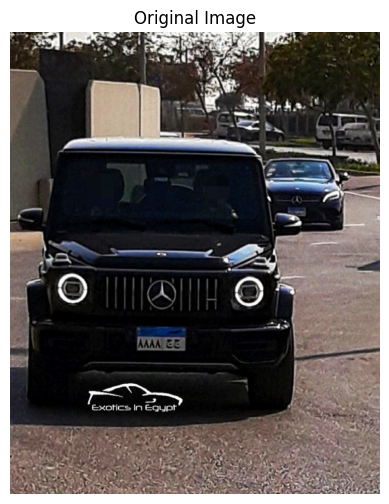

In [499]:
import importlib
import cv2
from pathlib import Path

import src.preprocessing as p
import src.detection as d
import src.utils as u

importlib.reload(p)
importlib.reload(d)
importlib.reload(u)

PROJECT_ROOT = Path("..").resolve()

image_path = PROJECT_ROOT / "Data" / "test_images" / "1826.jpg"

image = cv2.imread(str(image_path))

if image is None:
    raise ValueError("Image not found. Check image path.")

preprocessed = p.preprocess_image(image, width=900)

resized = preprocessed["resized"]
gray = preprocessed["gray"]

u.show_image("Original Image", resized)

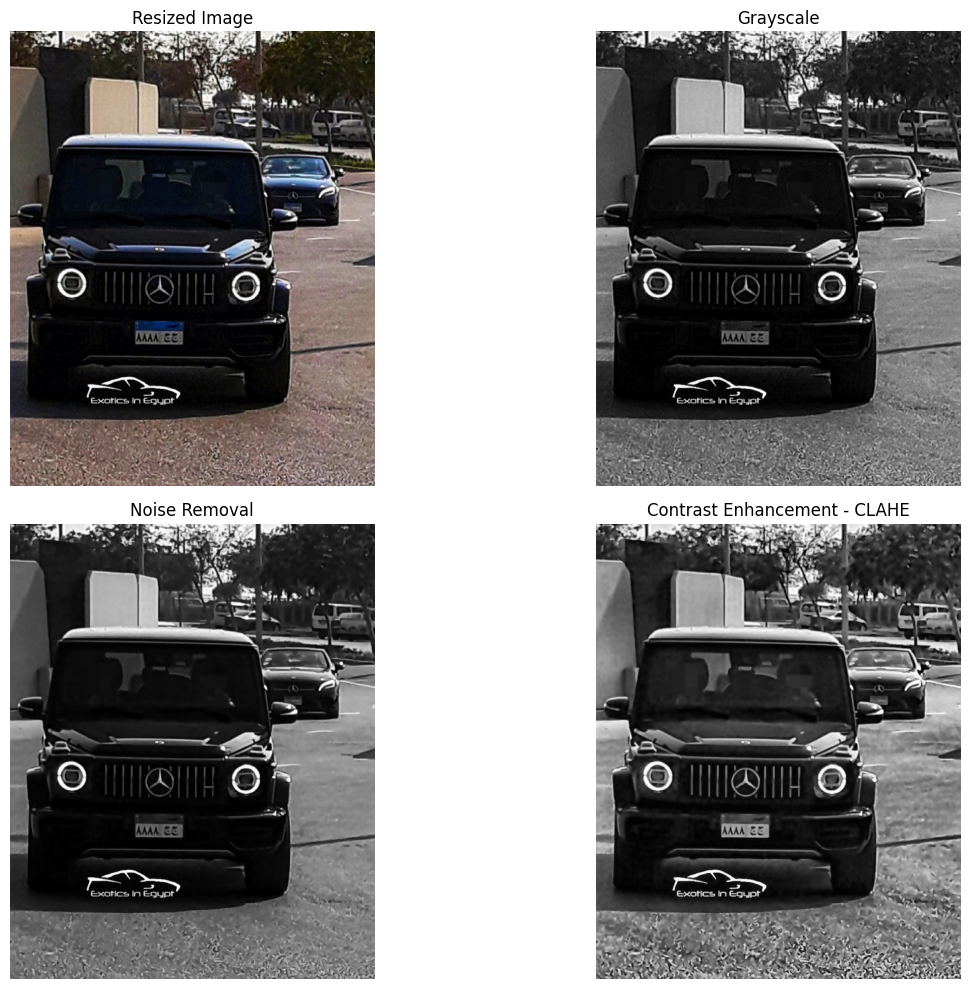

In [500]:
preprocessed = preprocess_image(image, width=900)

show_images_grid({
    "Resized Image": preprocessed["resized"],
    "Grayscale": preprocessed["gray"],
    "Noise Removal": preprocessed["denoised"],
    "Contrast Enhancement - CLAHE": preprocessed["enhanced"]
}, cols=2, figsize=(14, 10))

### Canny

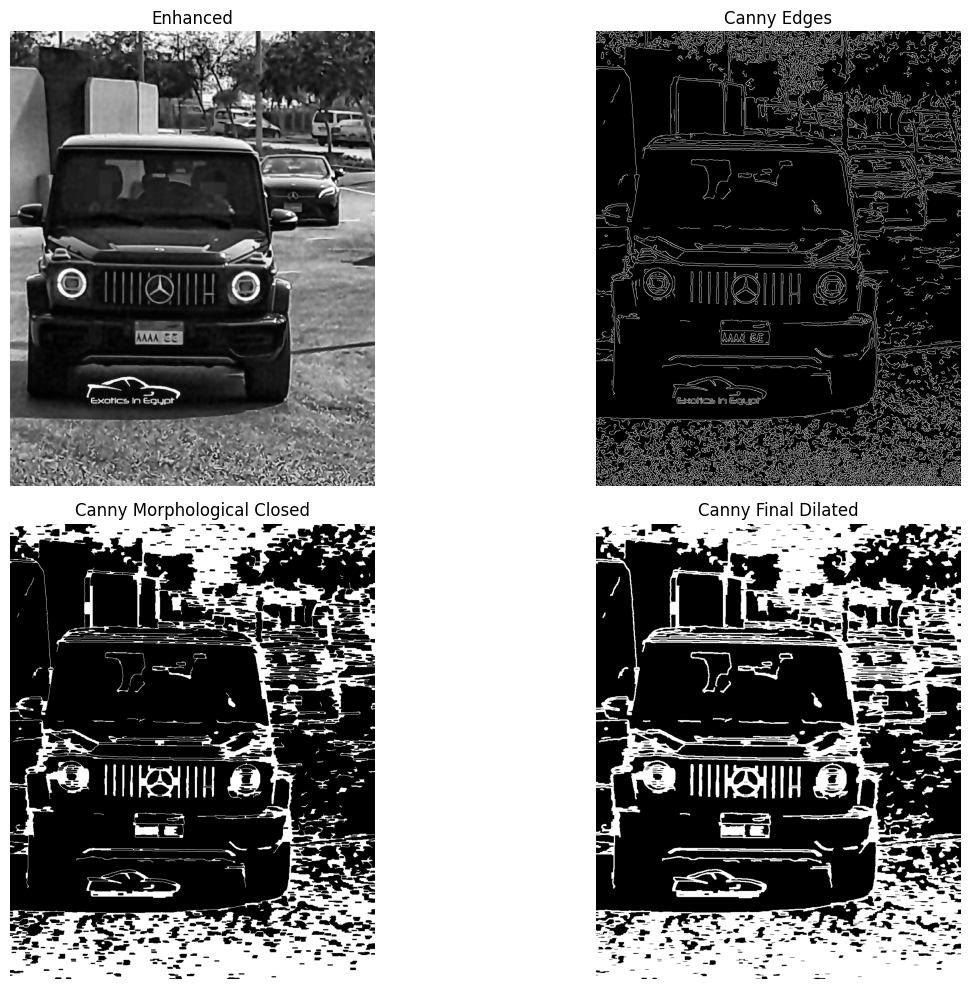

In [501]:
canny_output = d.canny_pipeline(gray)

u.show_images_grid({
    "Enhanced": canny_output["enhanced"],
    "Canny Edges": canny_output["edges"],
    "Canny Morphological Closed": canny_output["closed"],
    "Canny Final Dilated": canny_output["dilated"],
}, cols=2, figsize=(14, 10))

### canny Candidates

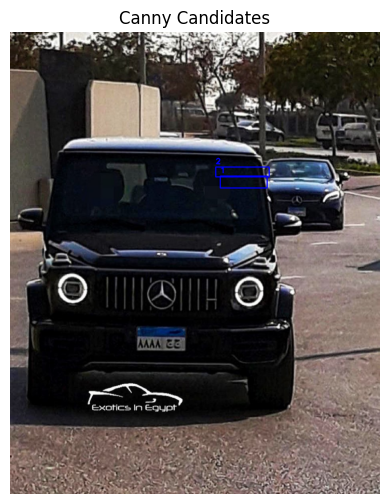

In [502]:
canny_candidates_image = d.draw_candidates(
    resized,
    canny_candidates
)

u.show_image(
    "Canny Candidates",
    canny_candidates_image
)

Canny Candidate 1
Box: (511, 350, 114, 29)
Aspect Ratio: 3.93
Area Ratio: 0.0033
Extent: 0.3
Center Y: 0.32
----------------------------------------


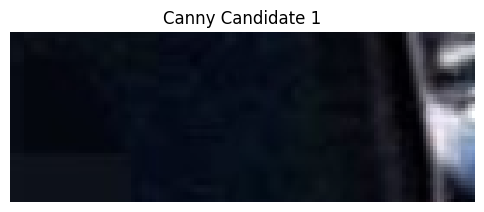

Canny Candidate 2
Box: (500, 328, 130, 24)
Aspect Ratio: 5.42
Area Ratio: 0.0031
Extent: 0.48
Center Y: 0.3
----------------------------------------


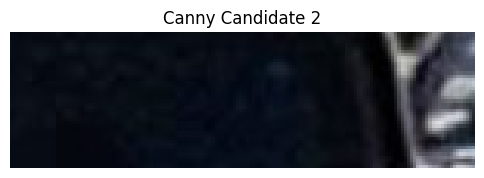

In [503]:
for i, candidate in enumerate(canny_candidates[:10]):
    crop = u.crop_with_padding(
        resized,
        candidate["box"],
        padding=10
    )

    print(f"Canny Candidate {i + 1}")
    print("Box:", candidate["box"])
    print("Aspect Ratio:", round(candidate["aspect_ratio"], 2))
    print("Area Ratio:", round(candidate["area_ratio"], 4))
    print("Extent:", round(candidate["extent"], 2))
    print("Center Y:", round(candidate["center_y"], 2))
    print("-" * 40)

    u.show_image(
        f"Canny Candidate {i + 1}",
        crop,
        figsize=(6, 3)
    )

### blackhat

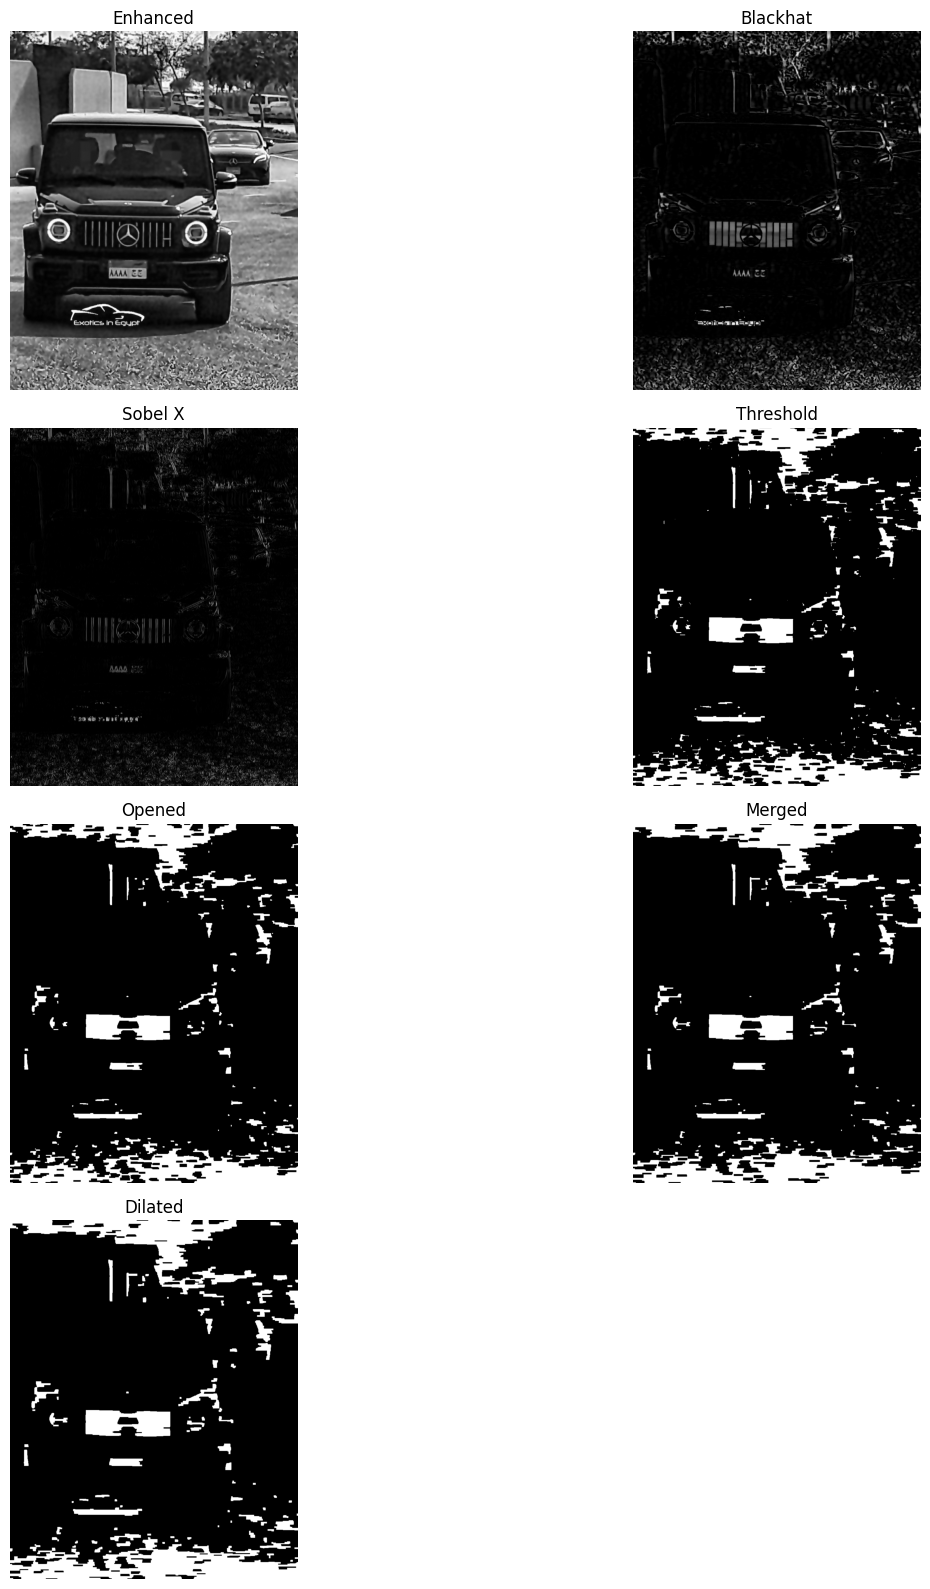

In [504]:
blackhat_output = d.blackhat_pipeline(gray)

u.show_images_grid({
    "Enhanced": blackhat_output["enhanced"],
    "Blackhat": blackhat_output["blackhat"],
    "Sobel X": blackhat_output["sobel_x"],
    "Threshold": blackhat_output["threshold"],
    "Opened": blackhat_output["opened"],
    "Merged": blackhat_output["merged"],
    "Dilated": blackhat_output["dilated"],
}, cols=2, figsize=(14, 16))

Blackhat Candidates: 11


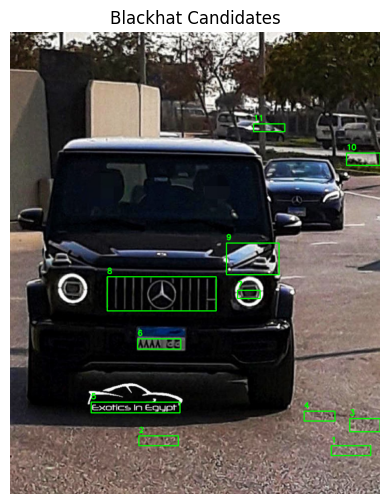

In [505]:
blackhat_candidates = d.extract_blackhat_candidates(
    blackhat_output["dilated"],
    resized
)

print("Blackhat Candidates:", len(blackhat_candidates))

blackhat_candidates_image = d.draw_candidates(
    resized,
    blackhat_candidates
)

u.show_image("Blackhat Candidates", blackhat_candidates_image)

Blackhat Candidate 1
Box: (781, 1006, 96, 24)
Aspect Ratio: 4.0
Rotated Aspect Ratio: 4.17
Area Ratio: 0.0023
Extent: 0.42
Center Y: 0.91
----------------------------------------


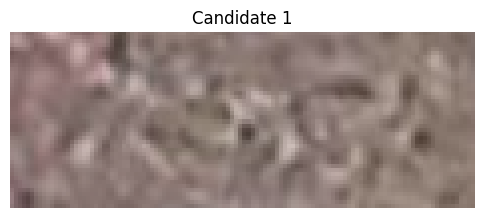

Blackhat Candidate 2
Box: (313, 982, 96, 24)
Aspect Ratio: 4.0
Rotated Aspect Ratio: 4.42
Area Ratio: 0.0023
Extent: 0.4
Center Y: 0.88
----------------------------------------


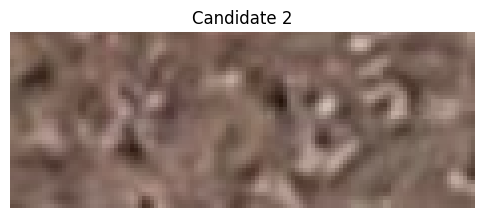

Blackhat Candidate 3
Box: (826, 940, 74, 32)
Aspect Ratio: 2.31
Rotated Aspect Ratio: 2.38
Area Ratio: 0.0023
Extent: 0.62
Center Y: 0.85
----------------------------------------


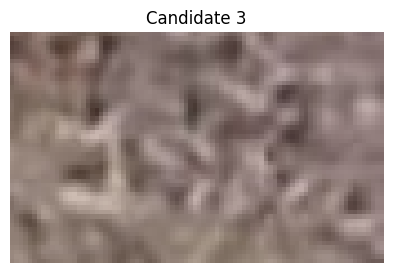

Blackhat Candidate 4
Box: (715, 922, 75, 24)
Aspect Ratio: 3.12
Rotated Aspect Ratio: 3.37
Area Ratio: 0.0018
Extent: 0.48
Center Y: 0.83
----------------------------------------


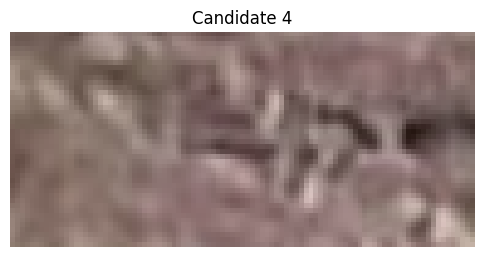

Blackhat Candidate 5
Box: (197, 900, 216, 26)
Aspect Ratio: 8.31
Rotated Aspect Ratio: 8.74
Area Ratio: 0.0056
Extent: 0.59
Center Y: 0.81
----------------------------------------


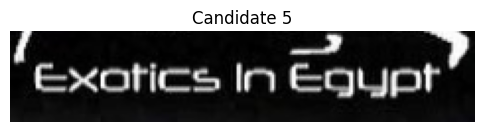

Blackhat Candidate 6
Box: (310, 746, 105, 25)
Aspect Ratio: 4.2
Rotated Aspect Ratio: 4.45
Area Ratio: 0.0026
Extent: 0.82
Center Y: 0.67
----------------------------------------


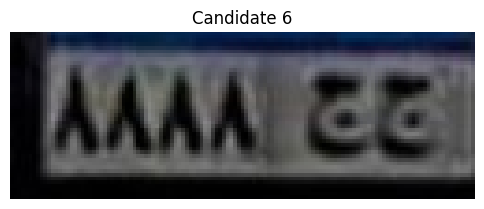

Blackhat Candidate 7
Box: (553, 628, 55, 20)
Aspect Ratio: 2.75
Rotated Aspect Ratio: 4.21
Area Ratio: 0.0011
Extent: 0.36
Center Y: 0.57
----------------------------------------


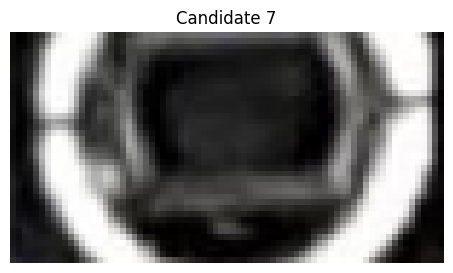

Blackhat Candidate 8
Box: (236, 595, 265, 83)
Aspect Ratio: 3.19
Rotated Aspect Ratio: 3.33
Area Ratio: 0.0217
Extent: 0.83
Center Y: 0.57
----------------------------------------


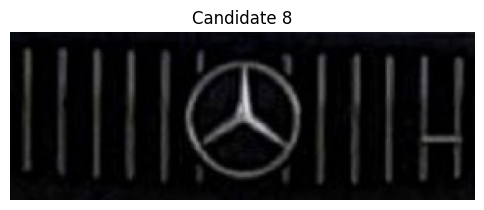

Blackhat Candidate 9
Box: (526, 513, 128, 77)
Aspect Ratio: 1.66
Rotated Aspect Ratio: 1.67
Area Ratio: 0.0097
Extent: 0.25
Center Y: 0.49
----------------------------------------


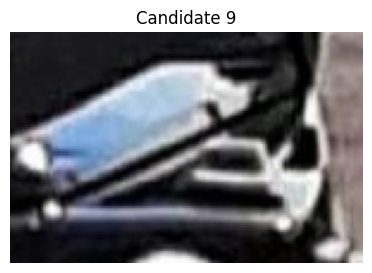

Blackhat Candidate 10
Box: (818, 294, 82, 30)
Aspect Ratio: 2.73
Rotated Aspect Ratio: 2.79
Area Ratio: 0.0024
Extent: 0.45
Center Y: 0.27
----------------------------------------


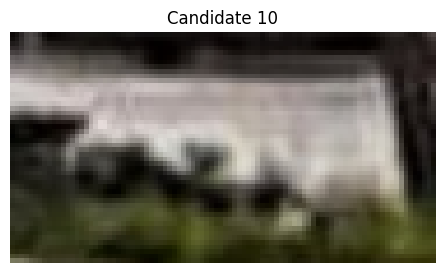

In [506]:
for i, candidate in enumerate(blackhat_candidates[:10]):
    crop = u.crop_with_padding(
        resized,
        candidate["box"],
        padding=10
    )

    print(f"Blackhat Candidate {i + 1}")
    print("Box:", candidate["box"])
    print("Aspect Ratio:", round(candidate["aspect_ratio"], 2))
    print("Rotated Aspect Ratio:", round(candidate["rotated_aspect_ratio"], 2))
    print("Area Ratio:", round(candidate["area_ratio"], 4))
    print("Extent:", round(candidate["extent"], 2))
    print("Center Y:", round(candidate["center_y"], 2))
    print("-" * 40)

    u.show_image(
        f"Candidate {i + 1}",
        crop,
        figsize=(6, 3)
    )

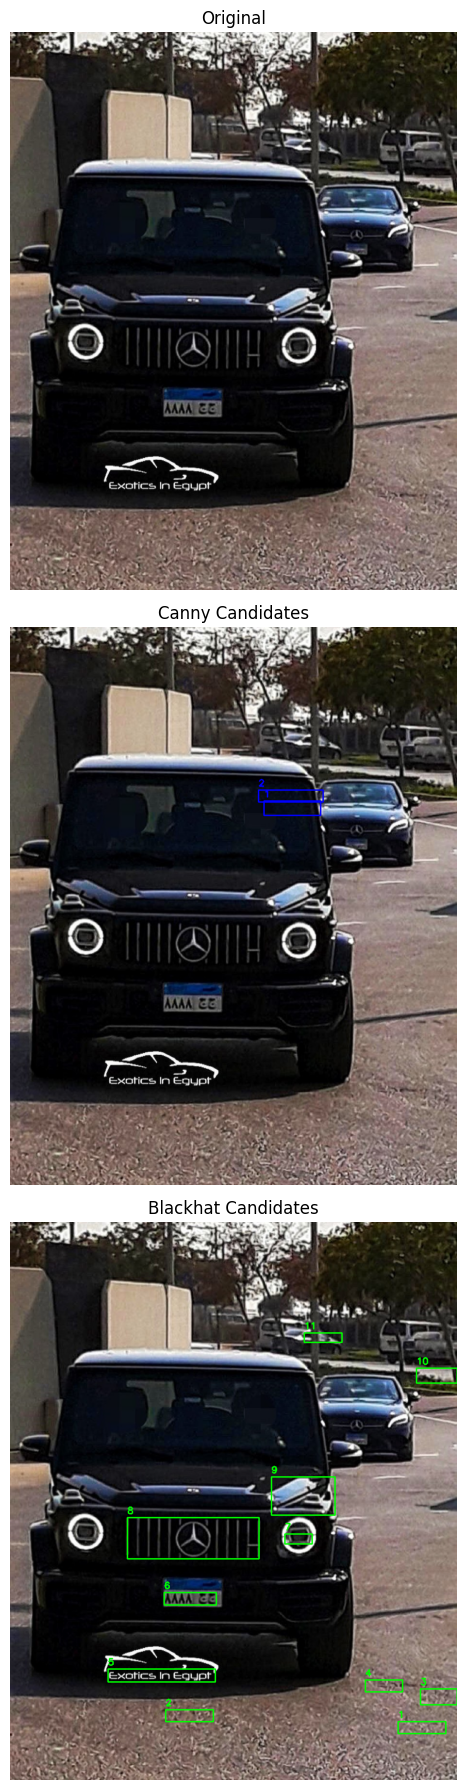

In [507]:
u.show_images_grid({
    "Original": resized,
    "Canny Candidates": canny_candidates_image,
    "Blackhat Candidates": blackhat_candidates_image,
}, cols=1, figsize=(12, 18))

In [510]:
import importlib
import src.scoring as s

importlib.reload(s)

ranked_blackhat_candidates = s.rank_blackhat_candidates(
    blackhat_candidates,
    blackhat_output["dilated"],
    resized.shape
)

top_3_blackhat = s.get_top_candidates(
    ranked_blackhat_candidates,
    top_n=5
)

print("All Blackhat Candidates:", len(blackhat_candidates))
print("Top 3:", len(top_3_blackhat))



All Blackhat Candidates: 11
Top 3: 5


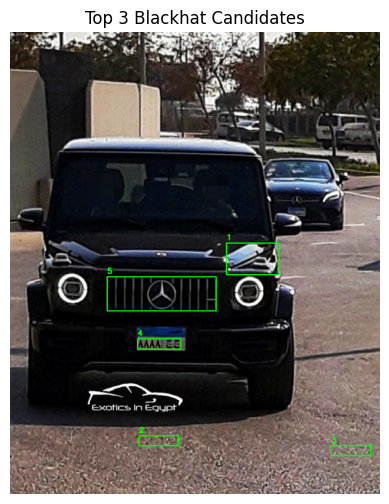

In [511]:
top_3_image = d.draw_candidates(
    resized,
    top_3_blackhat
)

u.show_image(
    "Top 3 Blackhat Candidates",
    top_3_image
)